<a href="https://colab.research.google.com/github/19matsiil/Tugas-Artificial-Intelligence/blob/main/(bd_dt)Linear_reg_ganda(09020624047).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [ ]:
data = {
    'harga':     [15, 18, 12, 20, 17, 14, 16, 19, 13, 21],
    'promosi':   [50, 40, 60, 30, 45, 55, 50, 35, 65, 25],
    'rating':    [4.5, 4.2, 4.8, 3.9, 4.3, 4.7, 4.4, 4.0, 4.9, 3.8],
    'penjualan': [200, 180, 250, 150, 190, 230, 210, 170, 260, 140]
}

df = pd.DataFrame(data)
print(df)

   harga  promosi  rating  penjualan
0     15       50     4.5        200
1     18       40     4.2        180
2     12       60     4.8        250
3     20       30     3.9        150
4     17       45     4.3        190
5     14       55     4.7        230
6     16       50     4.4        210
7     19       35     4.0        170
8     13       65     4.9        260
9     21       25     3.8        140


In [ ]:
x = df[['harga', 'promosi', 'rating']]
y = df['penjualan']
x_train,x_test,y_train,y_test = train_test_split(
    x, y,test_size=0.2,random_state=42
    )

In [ ]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
print("Intercept (a) : ", model.intercept_)
print("koefisien (b1,b2,b3) : ", model.coef_)
#b1(harga), b2(promosi), b3(rating). dengan arti bila harga naik, penjualan menurun, bila promosi banyak, penjualan naik, dan bila rating tinggi, penjualan naik.

Intercept (a) :  260.93749999999864
koefisien (b1,b2,b3) :  [-6.25   1.75  -9.375]


In [ ]:
y_pred = model.predict(x_test)
print("prediksi oenjualan : ", y_pred)
print("Penjualan Aktual : ", y_test.values)

prediksi :  [247.5    179.0625]
Nilai Asli :  [260 180]


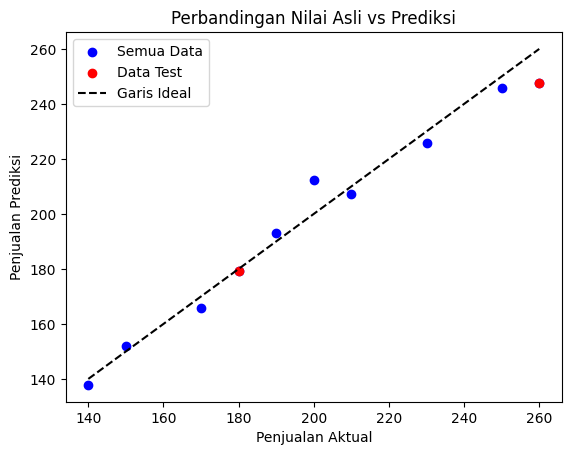

In [ ]:
import matplotlib.pyplot as plt

y_pred_all = model.predict(x)

plt.scatter(y, y_pred_all, color='blue', label='Semua Data')
plt.scatter(y_test, model.predict(x_test), color='red', label='Data Test')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label='Garis Ideal')
plt.xlabel("Penjualan Aktual")
plt.ylabel("Penjualan Prediksi")
plt.title("Perbandingan Penjualan Aktual vs Prediksi")
plt.legend()
plt.show()

In [ ]:
import numpy as np
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
#Nilai RMSE sebesar 8.86 pada skala penjualan 140–260 tergolong cukup baik, mengingat dataset yang digunakan sangat terbatas (hanya 10 data).

MAE: 6.718749999999972
MSE: 78.56445312499962
RMSE: 8.86365912730175


In [ ]:
data_baru = [[12, 60, 4.5]]
prediksi = model.predict(data_baru)
print("Prediksi penjualan:", round(prediksi[0], 2))
#Model memprediksi bahwa produk dengan harga 12, promosi 60, dan rating 4.5 akan menghasilkan 248.75 unit penjualan. Nilai ini masuk akal dan berada dalam rentang dataset training (140–260).


=== Prediksi Data Baru ===
Prediksi penjualan: 248.75


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
